<a href="https://colab.research.google.com/github/wavymejti/KursAI1/blob/main/konwulcje.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

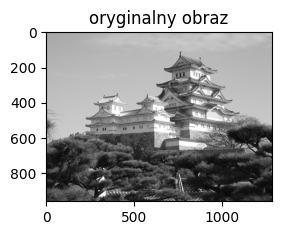

In [7]:
import cv2
import matplotlib.pyplot as plt

img = cv2.imread('himeji.jpg')
gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

plt.title("oryginalny obraz")
plt.imshow(gray, cmap='gray')

In [8]:
print(gray)

[[168 166 166 ... 179 179 179]
 [166 165 166 ... 179 180 181]
 [165 164 165 ... 179 182 184]
 ...
 [ 62  51  65 ...  36  35  34]
 [ 51  47  63 ...  37  31  26]
 [ 40  45  59 ...  30  31  32]]


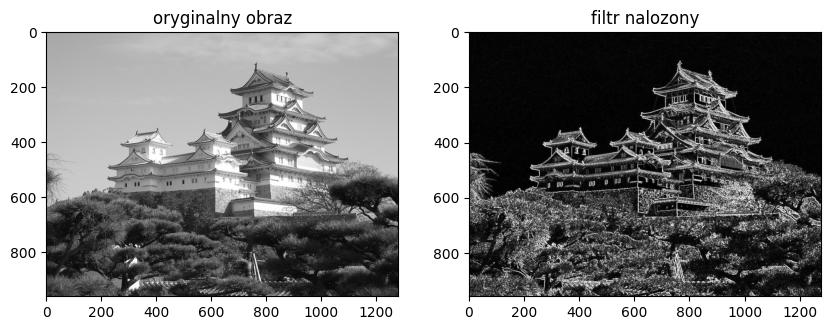

In [17]:
import numpy as np

def apply_filter(grayscale_img, filter_kernel):
  # wymiary obrazu
  image_height, image_width = grayscale_img.shape

  # output image
  filtered_image = np.zeros((image_height - 2, image_width - 2), dtype = np.float32)

  for y in range(1, image_height - 1):
    for x in range(1, image_width - 1):
      # wycinamy fragment obrazu 3x3 wokol aktualnego piksela
      neigborhoud = grayscale_img[y-1:y+2,x-1:x+2]
      # obliczamy wartosc konwulcji: suma elementów
      convultional_value = np.sum(neigborhoud * filter_kernel)
      # przepisujemy wynik do nowej macierzy
      filtered_image[y - 1, x - 1] = convultional_value

  filtered_image = np.abs(filtered_image)
  filtered_image = np.clip(filtered_image, 0, 255).astype(np.uint8)

  return filtered_image

#wykrywanie krawędzi pionowych
filtered_image = apply_filter(gray, np.array([
    [1, 0, -1],
    [1, 0, -1],
    [1, 0, -1]
    ]))

#wykrywanie krawędzi skośnych
filtered_image = apply_filter(gray, np.array([
    [0, 1, 2],
    [-1, 0, 1],
    [-2, -1, 0]
    ]))
plt.figure(figsize = (10, 4))

plt.subplot(1,2,1)
plt.title("oryginalny obraz")
plt.imshow(gray, cmap='gray')

plt.subplot(1,2,2)
plt.title("filtr nalozony")
plt.imshow(filtered_image, cmap='gray')

plt.show()